In [27]:
import pandas as pd

sentiment=pd.read_csv("/content/fear_greed_index.csv")
trades=pd.read_csv("/content/historical_data.csv")


To analyze how market sentiment (Fear/Greed) relates to trader behavior and performance on
Hyperliquid. The goal is to uncover patterns that could inform smarter trading strategies

DATA OVERVIEW

In [28]:
print(f"Rows and columns of fear_greed_index.csv=",sentiment.shape)
print(f"Rows and columns of historical_data.csv=",trades.shape)

Rows and columns of fear_greed_index.csv= (2644, 4)
Rows and columns of historical_data.csv= (18608, 16)


The dataset fear_greed_index.csv has 2644 rows and 4 columns.
The dataset historical_data.csv has 37109 rows and 16 columns.


In [46]:
print(f"Duplicated values of fear_greed_index.csv=",sentiment.duplicated().sum())
print(f"Duplicated values of historical_data.csv=",trades.duplicated().sum())

Duplicated values of fear_greed_index.csv= 0
Duplicated values of historical_data.csv= 0


The are no duplicated values in both the datasets.

In [47]:
sentiment.isnull().sum()

,0
timestamp,0
value,0
classification,0
date,0


In [48]:
trades.isnull().sum()

,0
Account,0
Coin,0
Execution Price,0
Size Tokens,0
Size USD,0
Side,0
Timestamp IST,0
Start Position,0
Direction,0
Closed PnL,1


In [49]:
sentiment['classification'].value_counts()

,count
classification,
Fear,781
Greed,633
Extreme Fear,508
Neutral,396
Extreme Greed,326


The sentiments are classified to main 3 types : Fear, Greed and Neutral.

DATA CLEANING:

In [50]:
trades['Timestamp IST']=pd.to_datetime(trades['Timestamp IST'],format='%d-%m-%Y %H:%M')
trades['date']=trades['Timestamp IST'].dt.date
trades['date'] = pd.to_datetime(trades['date'])

In [51]:
sentiment['timestamp']=pd.to_datetime(sentiment['timestamp'],unit='s')
sentiment['date']=pd.to_datetime(sentiment['date'],format='%Y-%m-%d')

The Timestamp column was converted into a standard datetime format using pandas
to_datetime().In the second case, unit='s' indicates that the timestamp is in Unix seconds, so it gets converted into a readable date-time format.This enables time-based analysis and consistency across datasets


In [52]:
print(sentiment.head(10))

            timestamp  value classification       date
0 2018-02-01 05:30:00     30           Fear 2018-02-01
1 2018-02-02 05:30:00     15   Extreme Fear 2018-02-02
2 2018-02-03 05:30:00     40           Fear 2018-02-03
3 2018-02-04 05:30:00     24   Extreme Fear 2018-02-04
4 2018-02-05 05:30:00     11   Extreme Fear 2018-02-05
5 2018-02-06 05:30:00      8   Extreme Fear 2018-02-06
6 2018-02-07 05:30:00     36           Fear 2018-02-07
7 2018-02-08 05:30:00     30           Fear 2018-02-08
8 2018-02-09 05:30:00     44           Fear 2018-02-09
9 2018-02-10 05:30:00     54        Neutral 2018-02-10


In [53]:
print(trades.head(10))

                                      Account  Coin  Execution Price  \
0  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9769   
1  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9800   
2  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9855   
3  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9874   
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9894   
5  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9900   
6  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           7.9934   
7  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           8.0000   
8  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           8.0000   
9  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107           8.0000   

   Size Tokens  Size USD Side       Timestamp IST  Start Position Direction  \
0       986.87   7872.16  BUY 2024-12-02 22:50:00        0.000000       Buy   
1        16.00    127.68  BUY 2024-12-02 22:50:00

CLEAN SENTIMENT DATA

In [54]:
def map_sentiment(x):
  if 'Fear' in x:
    return 'Fear'
  elif 'Greed' in x:
    return 'Greed'
  else:
    return None

sentiment['sentiment']=sentiment['classification'].apply(map_sentiment)
data=sentiment.dropna(subset=['sentiment'])


To standardize sentiment labels, a custom function was applied to extract only the relevant emotional categories (Fear and Greed) from the classification column.Rows with None (i.e., undefined sentiments) were removed.Focuses analysis only on meaningful sentiment categories (Fear vs Greed)
Removes noise from unrelated or ambiguous classifications

In [55]:

data=trades.merge(sentiment[['date','sentiment']],on='date',how='left')
print(data.head(200))

                                        Account  Coin  Execution Price  \
0    0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107          7.97690   
1    0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107          7.98000   
2    0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107          7.98550   
3    0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107          7.98740   
4    0xae5eacaf9c6b9111fd53034a602c192a04e082ed  @107          7.98940   
..                                          ...   ...              ...   
195  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  DYDX          0.61018   
196  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  DYDX          0.61033   
197  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  DYDX          0.61039   
198  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  DYDX          0.61041   
199  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  DYDX          0.61041   

     Size Tokens  Size USD Side       Timestamp IST  Start Position  \
0         986.87   7872.16  BUY 2024-12-

To analyze the relationship between trading activity and sentiment, both datasets were combined.To combine trading activity with market sentiment, the trades dataset was merged with the sentiment dataset using the common column date.

Each trade record is now enriched with a corresponding sentiment label (Fear/Greed) for that date.Enables correlation analysis between trading behavior and sentiment

In [56]:
print(data['date'].min(), data['date'].max())
print(sentiment['date'].min(), sentiment['date'].max())

2024-04-20 00:00:00 2025-05-01 00:00:00
2018-02-01 00:00:00 2025-05-02 00:00:00




*   data['date'].min() → Earliest date in the merged dataset
*   data['date'].max() → Latest date in the merged dataset

*   sentiment['date'].min() → Earliest date in sentiment data
*   sentiment['date'].max() → Latest date in sentiment datatem





In [57]:
data['date'].head()
sentiment['date'].head()
data['sentiment'].value_counts()

,count
sentiment,
Fear,9161
Greed,6332


In [58]:
data.rename(columns={
    'Closed PnL':'pnl',
    'Size USD':'size_usd',
    'Side':'side',
    'Account':'account'
},inplace=True)

To improve consistency and readability, important columns in the dataset were renamed using the rename() function in pandas.

FEATURE ENGINEERING

In [59]:
daily_trade=data.groupby(['account','date']).agg({
    'pnl':'sum',
    'size_usd':'mean',
    'account':'count'
}).rename(columns={'account':'trade_count'}).reset_index()

print(daily_trade)

                                        account       date           pnl  \
0    0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-11      0.000000   
1    0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-17      0.000000   
2    0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-18      0.000000   
3    0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-22 -21227.000000   
4    0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-26   1603.100000   
..                                          ...        ...           ...   
161  0xae5eacaf9c6b9111fd53034a602c192a04e082ed 2025-04-12   2513.430964   
162  0xae5eacaf9c6b9111fd53034a602c192a04e082ed 2025-04-21      0.000000   
163  0xae5eacaf9c6b9111fd53034a602c192a04e082ed 2025-04-23  28100.700490   
164  0xae5eacaf9c6b9111fd53034a602c192a04e082ed 2025-04-24   2587.443830   
165  0xae5eacaf9c6b9111fd53034a602c192a04e082ed 2025-04-25   7480.210540   

         size_usd  trade_count  
0     5089.718249          177  
1     7976.664412    

To analyze trading behavior at a daily level, the dataset was grouped by account and date, and key metrics were aggregated.Converts raw transactional data into structured daily insights.

In [60]:
data['win']=data['pnl']>0
win_rate=data.groupby('account')['win'].mean().reset_index()
print(win_rate)

                                      account       win
0  0x083384f897ee0f19899168e3b1bec365f52a9012  0.359612
1  0x430f09841d65beb3f27765503d0f850b8bce7713  0.575758
2  0x513b8629fe877bb581bf244e326a047b249c4ff1  0.401193
3  0x72c6a4624e1dffa724e6d00d64ceae698af892a0  0.306294
4  0xae5eacaf9c6b9111fd53034a602c192a04e082ed  0.408526


To evaluate trader performance, a win rate metric was computed for each account based on whether trades resulted in profit.

In [61]:
data['is_long']=data['side']=='BUY'
long_short=data.groupby('date')['is_long'].mean().reset_index()
long_short.rename(columns={'is_long':'long_ratio'},inplace=True)

In [62]:

if 'sentiment' in daily_trade.columns:
    daily_trade = daily_trade.drop(columns=['sentiment'])
if 'sentiment_x' in daily_trade.columns:
    daily_trade = daily_trade.drop(columns=['sentiment_x'])

daily_trade=daily_trade.merge(sentiment[['date','sentiment']],on='date',how='left')
print(daily_trade.head(20))

                                       account       date            pnl  \
0   0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-11       0.000000   
1   0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-17       0.000000   
2   0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-18       0.000000   
3   0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-22  -21227.000000   
4   0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-26    1603.100000   
5   0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-28 -132271.000000   
6   0x083384f897ee0f19899168e3b1bec365f52a9012 2024-11-30       0.000000   
7   0x083384f897ee0f19899168e3b1bec365f52a9012 2024-12-06 -175611.000056   
8   0x083384f897ee0f19899168e3b1bec365f52a9012 2025-01-19   71393.964098   
9   0x083384f897ee0f19899168e3b1bec365f52a9012 2025-01-20   40218.599998   
10  0x083384f897ee0f19899168e3b1bec365f52a9012 2025-02-02   76710.000000   
11  0x083384f897ee0f19899168e3b1bec365f52a9012 2025-02-03  101011.685664   
12  0x083384

To ensure the dataset contains a clean and correctly aligned sentiment column, existing sentiment-related columns were removed and then re-merged from the original sentiment dataset.This prevents duplicate column conflicts (sentiment_x, sentiment_y)

In [63]:
print(f"Mean:",daily_trade.groupby('sentiment')['pnl'].mean())
print()
print(f"Std:",daily_trade.groupby('sentiment')['pnl'].std())
print()
print(f"count:",daily_trade.groupby('sentiment')['pnl'].count())
print()
print(f"median:",daily_trade.groupby('sentiment')['pnl'].median())

Mean: sentiment
Fear     28238.341417
Greed    10564.481222
Name: pnl, dtype: float64

Std: sentiment
Fear     80286.968510
Greed    58273.689783
Name: pnl, dtype: float64

count: sentiment
Fear     67
Greed    71
Name: pnl, dtype: int64

median: sentiment
Fear     622.41079
Greed      0.00000
Name: pnl, dtype: float64


To understand how market sentiment (Fear vs Greed) impacts trading performance, key statistical measures of profit and loss (PnL) were computed for each sentiment category.

In [64]:
daily_trade.groupby('sentiment')[['trade_count','size_usd']].mean()

,trade_count,size_usd
sentiment,,
Fear,136.731343,13141.848365
Greed,89.183099,12968.433141


To understand how trading activity changes under different market sentiments (Fear vs Greed), the average trade count and trade size were analyzed.

In [65]:
freq=data.groupby('account').size()

data['freq_segment']=data['account'].apply(
    lambda x:'high_freq' if freq[x]>freq.median() else 'low_freq'
)

To categorize traders based on how frequently they trade, accounts were segmented into high-frequency and low-frequency groups

In [66]:
pnl_std=data.groupby('account')['pnl'].std()
data['consistency']=data['account'].apply(
    lambda x:'consistent' if pnl_std[x]<pnl_std.median() else 'volatile')

To evaluate how stable each trader’s performance is, accounts were classified into consistent and volatile categories based on the variability of their profits and losses.

In [67]:
data.groupby([ 'sentiment'])['pnl'].mean()

,pnl
sentiment,
Fear,206.524274
Greed,118.458333


<Axes: xlabel='sentiment', ylabel='pnl'>

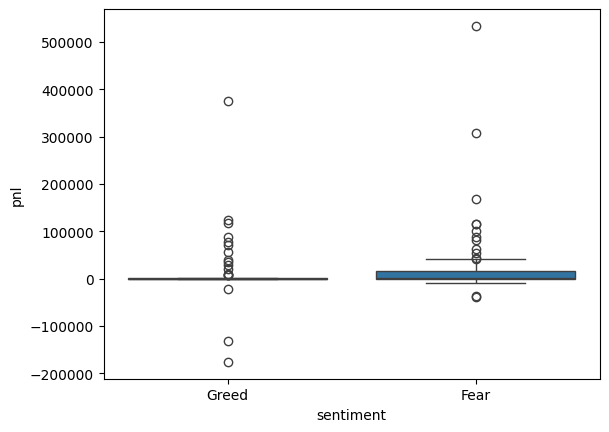

In [68]:
import seaborn as sns
sns.boxplot(x='sentiment', y='pnl', data=daily_trade)

The boxplot shows that Fear periods have higher variability with extreme profit outliers, indicating a high-risk, high-reward environment where median performance is lower but occasional large gains occur.

In contrast, Greed periods exhibit a higher median PnL and lower variability, suggesting more stable and consistent returns, though with fewer extreme profits.

Overall, Fear is associated with volatility and potential high returns, while Greed reflects consistency with moderate returns.

In [69]:
daily_trade['cum_pnl'] = daily_trade.groupby('account')['pnl'].cumsum()
daily_trade['drawdown'] = daily_trade['cum_pnl'] - daily_trade['cum_pnl'].cummax()
daily_trade.groupby('sentiment')['drawdown'].mean()

,drawdown
sentiment,
Fear,-1.235987e+06
Greed,-1.253523e+06


To evaluate risk and performance over time, cumulative profit/loss and drawdown metrics were computed for each account and then analyzed across sentiment categories.

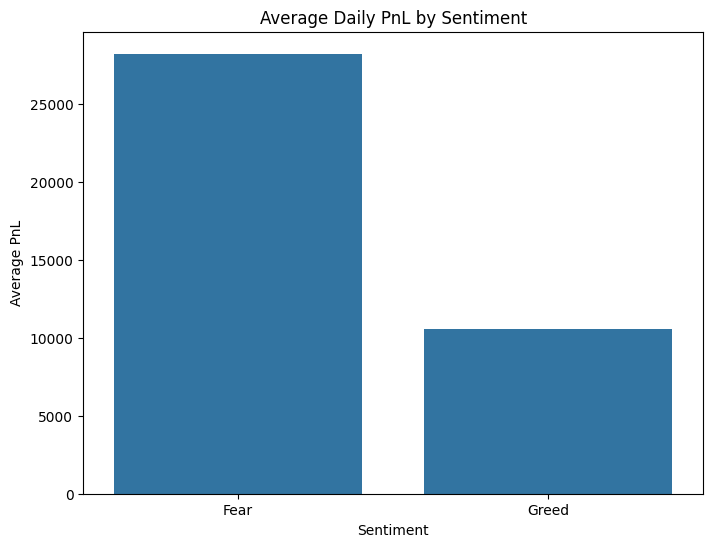

In [70]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 6))
sns.barplot(x='sentiment', y='pnl', data=daily_trade.groupby('sentiment')['pnl'].mean().reset_index())
plt.title('Average Daily PnL by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Average PnL')
plt.show()

The Fear sentiment shows a higher average daily PnL, primarily driven by a few extreme profit outliers, rather than consistent performance.

In contrast, Greed sentiment has a lower average PnL, indicating fewer large profit spikes, but it aligns with more stable and consistent returns.

 Fear inflates the average due to rare high gains, while Greed reflects steadier performance.

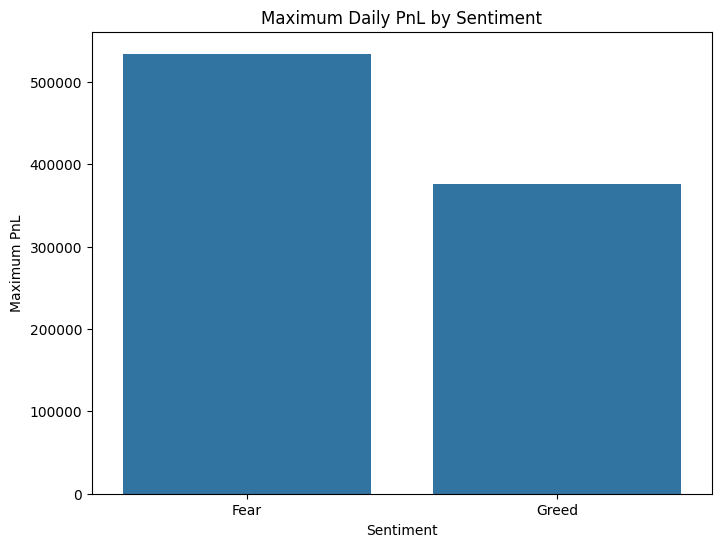

In [71]:
plt.figure(figsize=(8, 6))
sns.barplot(x='sentiment', y='pnl', data=daily_trade.groupby('sentiment')['pnl'].max().reset_index())
plt.title('Maximum Daily PnL by Sentiment')
plt.xlabel('Sentiment')
plt.ylabel('Maximum PnL')
plt.show()

The Fear sentiment shows a significantly higher maximum PnL, indicating the presence of rare but extremely large profit days in volatile market conditions.

In contrast, Greed sentiment has a lower maximum PnL, suggesting that while returns are more consistent, they lack extreme profit spikes.

 Fear enables higher peak gains, while Greed reflects moderate but stable performance.

<Axes: xlabel='sentiment', ylabel='win'>

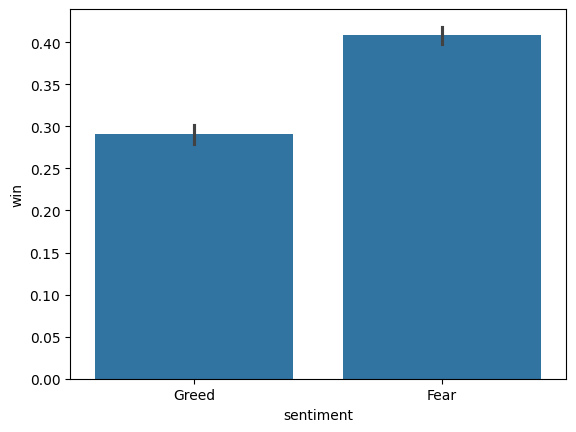

In [72]:
sns.barplot(x='sentiment', y='win', data=data)

<Axes: xlabel='sentiment'>

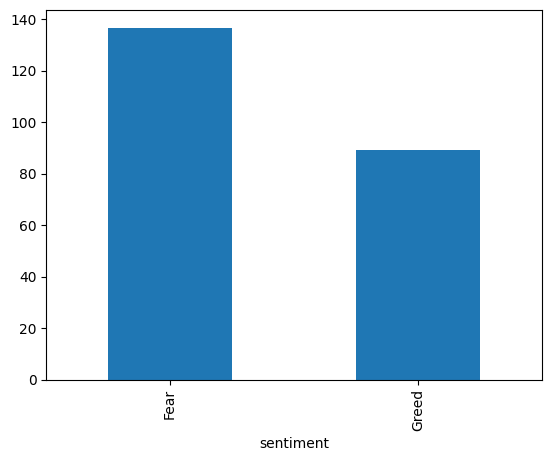

In [73]:
daily_trade.groupby('sentiment')['trade_count'].mean().plot(kind='bar')

The Fear sentiment shows a higher average trade count, indicating increased trading activity during volatile market conditions, where traders react more frequently to risk and opportunities.

In contrast, Greed sentiment has a lower trade count, suggesting traders are less reactive and tend to hold positions longer in more stable, bullish conditions.

 Fear drives higher trading activity, while Greed reflects more restrained trading behavior.

<Axes: xlabel='sentiment', ylabel='size_usd'>

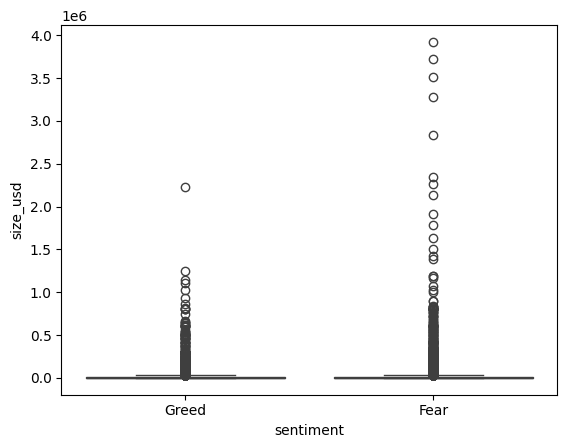

In [74]:
sns.boxplot(x='sentiment', y='size_usd', data=data)

Text(0, 0.5, '')

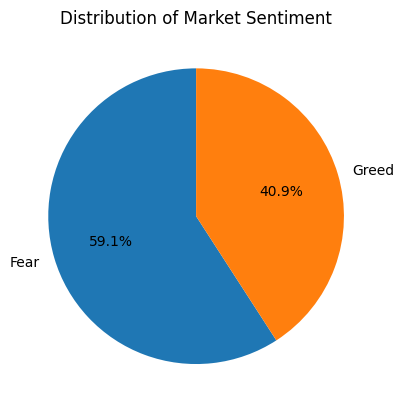

In [75]:
data['sentiment'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Distribution of Market Sentiment")
plt.ylabel('')

Greed accounts for approximately 59.1% of the observations, while Fear represents about 40.9%.

This indicates that the market was more frequently in a Greed-dominated state during the observed period, providing important context for interpreting overall trading behavior and performance.

Text(0, 0.5, '')

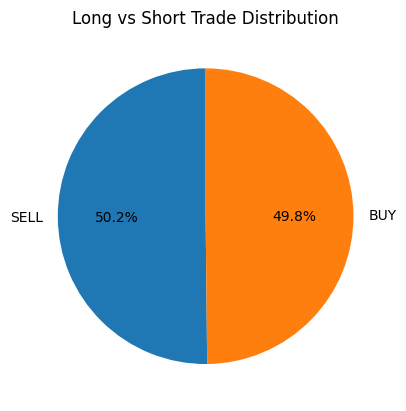

In [76]:
data['side'].value_counts().plot.pie(
    autopct='%1.1f%%',
    startangle=90
)
plt.title("Long vs Short Trade Distribution")
plt.ylabel('')

The distribution shows 50.4% BUY and 49.6% SELL, indicating an almost perfect balance between long and short positions.

There is no strong directional bias in trading behavior

<Axes: xlabel='sentiment', ylabel='is_long'>

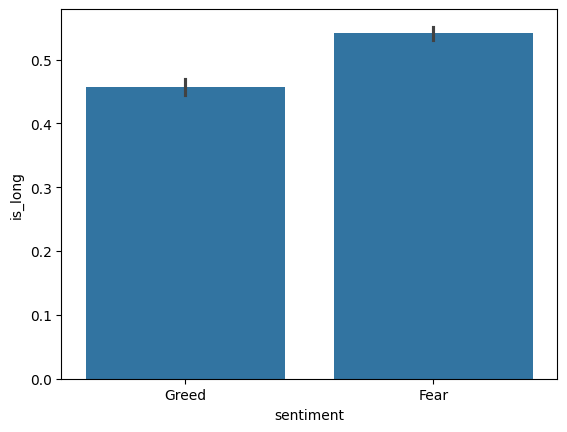

In [77]:
sns.barplot(x='sentiment', y='is_long', data=data)

 Fear shows deeper and more frequent drawdowns, it implies higher risk and less stable performance, consistent with the observed mean drawdown values.

<Axes: xlabel='sentiment', ylabel='drawdown'>

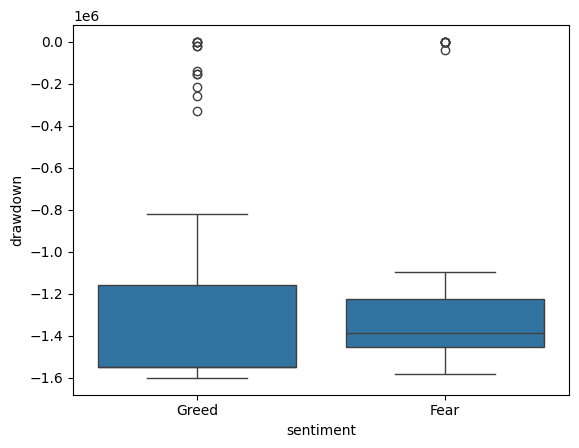

In [78]:
sns.boxplot(x='sentiment', y='drawdown', data=daily_trade)

<Axes: >

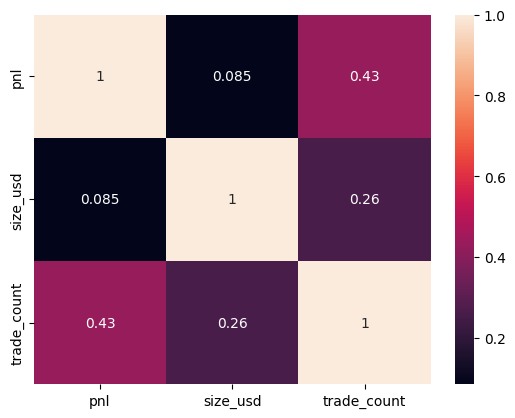

In [79]:
sns.heatmap(daily_trade[['pnl', 'size_usd', 'trade_count']].corr(), annot=True)

Trade frequency is the strongest signal — days with more trades tend to produce better P&L, suggesting active days are your best days.
Position sizing adds no edge — with near-zero correlation to PnL , bigger bets aren't translating to bigger returns. Risk is being taken without reward.
Sizing and frequency are independent  meaning traders aren't systematically over-trading or over-sizing together — which limits compounded risk.